**Цель эксперимента** — оценить влияние нового дизайна лендинга на конверсию пользователей.

Под конверсией понимается факт совершения целевого действия пользователем при посещении лендинга.  
Результаты эксперимента используются для принятия решения о внедрении нового дизайна.


Формулируем следующие гипотезы:

H₀ (нулевая гипотеза):  
Конверсия пользователей в тестовой и контрольной группах не отличается.

H₁ (альтернативная гипотеза):  
Конверсия пользователей в тестовой и контрольной группах различается.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
df = pd.read_csv("сontent/data.csv", header=0)

In [3]:
df

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


Для анализа используются данные A/B-теста, содержащие информацию о действиях пользователей.

Основные поля:
- user_id — идентификатор пользователя
- group — группа эксперимента (control / treatment)
- landing_page — версия страницы
- converted — факт конверсии (1 — да, 0 — нет)
- timestamp — время события

Каждый пользователь должен принадлежать только к одной группе и видеть соответствующую версию лендинга.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [5]:
df.groupby('group')['user_id'].count()

group
control      147202
treatment    147276
Name: user_id, dtype: int64

In [ ]:
df['group'].unique()

array(['control', 'treatment'], dtype=object)

In [7]:
df['landing_page'].unique()

array(['old_page', 'new_page'], dtype=object)

In [8]:
df['converted'].unique()

array([0, 1])

In [9]:
df[((df['group']=='treatment')==(df['landing_page']=='new_page')) == False]

,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0
...,...,...,...,...,...
294014,813406,2017-01-09 06:25:33.223301,treatment,old_page,0
294200,928506,2017-01-13 21:32:10.491309,control,new_page,0
294252,892498,2017-01-22 01:11:10.463211,treatment,old_page,0
294253,886135,2017-01-06 12:49:20.509403,control,new_page,0


In [10]:
df_res = df[((df['group']=='treatment')==(df['landing_page']=='new_page')) == True]
df_res.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290585 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       290585 non-null  int64 
 1   timestamp     290585 non-null  object
 2   group         290585 non-null  object
 3   landing_page  290585 non-null  object
 4   converted     290585 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 13.3+ MB


In [11]:
df_res.loc[df_res.duplicated(['user_id'])]

,user_id,timestamp,group,landing_page,converted
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [12]:
df_res[df_res['user_id'] == 773192]

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [13]:
df_res.drop_duplicates(subset='user_id', keep='last', inplace=True)

/tmp/ipykernel_20/204109504.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res.drop_duplicates(subset='user_id', keep='last', inplace=True)


In [14]:
df_res['user_id'].nunique()

290584

Перед проведением статистического тестирования была выполнена проверка корректности эксперимента.

В ходе анализа выявлены следующие проблемы:
- часть пользователей из контрольной группы видела тестовую версию страницы и наоборот;
- в данных присутствуют повторяющиеся пользователи.

Для обеспечения корректности эксперимента:
- удалены пользователи с несоответствием группы и версии страницы;
- для каждого пользователя оставлено одно наблюдение.


Разделим наших пользователей на две группы: контрольную и тестовую

In [15]:
df_ctrl = df_res[df_res['group'] == 'control']
df_test = df_res[df_res['group'] == 'treatment']

In [16]:
print(f"Размер контрольной выборки: {len(df_ctrl)}")
print(f"Размер тестовой выборки: {len(df_test)}")

Размер контрольной выборки: 145274
Размер тестовой выборки: 145310


Итоговые размеры выборок практически одинаковые.

Посмотрим на соотношение конверсии по пользователям в каждой из групп.

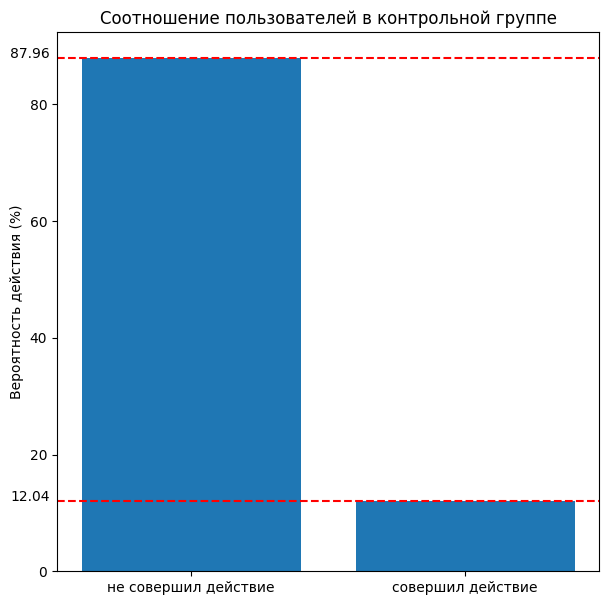

In [ ]:

p_ctrl = df_ctrl['converted'].sum() / len(df_ctrl)

fig = plt.figure(figsize = (7, 7))

plt.bar(['не совершил действие', 'совершил действие'],
        [(1 - p_ctrl)*100, p_ctrl*100])
plt.title('Соотношение пользователей в контрольной группе')
plt.ylabel('Вероятность действия (%)')
plt.axhline (y=p_ctrl*100, color='red', linestyle='--')
plt.axhline (y=(1-p_ctrl)*100, color='red', linestyle='--')
plt.text(x=-.66, y=p_ctrl*100, s='{:.2f}'.format(p_ctrl*100))
plt.text(x=-.66, y=(1-p_ctrl)*100, s='{:.2f}'.format(100 - p_ctrl*100))

plt.show()

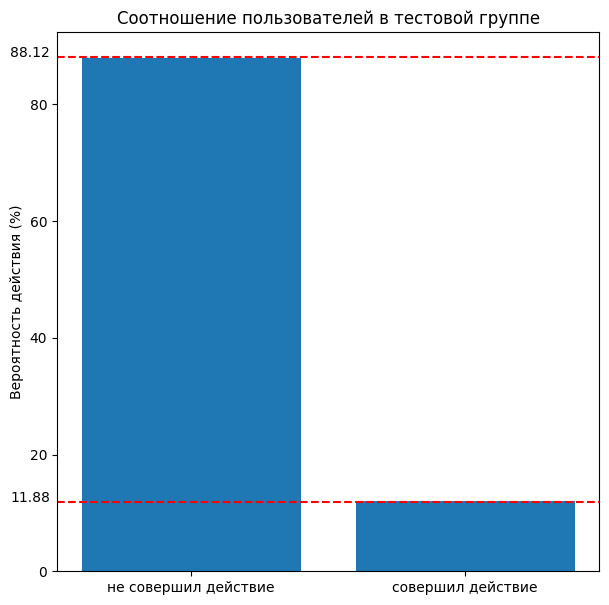

In [ ]:

p_test = df_test['converted'].sum() / len(df_test)

fig = plt.figure(figsize = (7, 7))

plt.bar(['не совершил действие', 'совершил действие'], [(1 - p_ctrl)*100, p_ctrl*100])
plt.title('Соотношение пользователей в тестовой группе')
plt.ylabel('Вероятность действия (%)')
plt.axhline (y=p_test*100, color='red', linestyle='--')
plt.axhline (y=(1-p_test)*100, color='red', linestyle='--')
plt.text(x=-.66, y=p_test*100, s='{:.2f}'.format(p_test*100))
plt.text(x=-.66, y=(1-p_test)*100, s='{:.2f}'.format(100 - p_test*100))

plt.show()

Соотношение примерно одинаковое, даже в контрольной группе чуть больше, там 12.04% пользователей совершают целевое действие, против 11.88% в тестовой группе. Проверим, является ли эта разница статистически значимой.

In [19]:
ese = sqrt(p_ctrl * (1 - p_ctrl) / len(df_ctrl) + \
           p_test * (1 - p_test) / len(df_ctrl))
ese

0.0012039846676905476

In [20]:
z = (p_ctrl - p_test) / ese
z

1.3108464149987011

Получили значение z-статистики равное $\approx 1.31$

Согласно таблицам, при таком значении z-статистики $p-value = 0,19$

Проверим расчеты с помощью встроенных библиотек.

In [21]:
count = [df_ctrl['converted'].sum(), df_test['converted'].sum()]

In [22]:
count

[17489, 17264]

In [23]:
nobs = [df_ctrl['converted'].count(), df_test['converted'].count()]

In [24]:
nobs

[145274, 145310]

In [25]:
z_stat, pval = proportions_ztest(count, nobs)

In [26]:
print("Значение z-статистики: {:.2f}".format(z_stat))
print("Значение p-value: {:.2f}".format(pval))

Значение z-статистики: 1.31
Значение p-value: 0.19


# Итог:
Получившееся значение $p-value > 0,05$,следовательно мы не имеем достаточных оснований для отклонения нулевой гипотезы о том, что изменение дизайна лендинговой страницы никак не повлияло на конверсию.

Поэтому, мы не можем рекомендовать внедрять новый дизайн.

# Дополнительное исследование
Для более глубокого понимания результатов был проведён дополнительный анализ конверсии во времени.

Анализ по дням показал наличие аномального дня(14-е января, а также период с 11-го по 16-е) с резким отклонением конверсии в обеих группах.
Это может указывать на влияние внешнего фактора (например, маркетинговая активность или технические изменения).


In [27]:
df_res['date_only'] = df_res['timestamp'].str.split(' ', n = 1, expand = False).apply(lambda x: x[0])

/tmp/ipykernel_20/426141294.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['date_only'] = df_res['timestamp'].str.split(' ', n = 1, expand = False).apply(lambda x: x[0])


In [28]:
df_res

,user_id,timestamp,group,landing_page,converted,date_only
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,2017-01-21
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,2017-01-12
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,2017-01-11
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,2017-01-08
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,2017-01-21
...,...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0,2017-01-03
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0,2017-01-12
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0,2017-01-22
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0,2017-01-15


In [29]:
df_date = df_res.groupby(['group', 'date_only']). \
          agg(user_count=('user_id','count'),
              converted_sum=('converted','sum')). \
          reset_index()

In [30]:
df_date

,group,date_only,user_count,converted_sum
0,control,2017-01-02,2859,359
1,control,2017-01-03,6590,750
2,control,2017-01-04,6578,802
3,control,2017-01-05,6427,792
4,control,2017-01-06,6606,762
5,control,2017-01-07,6604,799
6,control,2017-01-08,6687,795
7,control,2017-01-09,6628,793
8,control,2017-01-10,6654,751
9,control,2017-01-11,6688,795


In [31]:
df_date_ctrl = df_date[df_date['group'] == 'control']
df_date_test = df_date[df_date['group'] == 'treatment'].reset_index()

In [32]:
df_date_ctrl

,group,date_only,user_count,converted_sum
0,control,2017-01-02,2859,359
1,control,2017-01-03,6590,750
2,control,2017-01-04,6578,802
3,control,2017-01-05,6427,792
4,control,2017-01-06,6606,762
5,control,2017-01-07,6604,799
6,control,2017-01-08,6687,795
7,control,2017-01-09,6628,793
8,control,2017-01-10,6654,751
9,control,2017-01-11,6688,795


In [33]:
df_date_test

,index,group,date_only,user_count,converted_sum
0,23,treatment,2017-01-02,2853,342
1,24,treatment,2017-01-03,6618,753
2,25,treatment,2017-01-04,6541,763
3,26,treatment,2017-01-05,6505,748
4,27,treatment,2017-01-06,6747,833
5,28,treatment,2017-01-07,6609,768
6,29,treatment,2017-01-08,6700,809
7,30,treatment,2017-01-09,6614,781
8,31,treatment,2017-01-10,6696,846
9,32,treatment,2017-01-11,6673,768


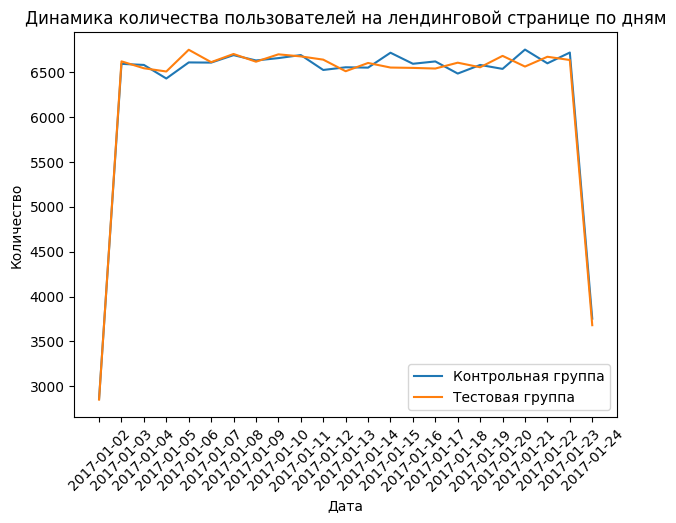

In [34]:
fig = plt.figure(figsize = (7, 5))

plt.plot(df_date_ctrl['date_only'],
         df_date_ctrl['user_count'],
         label = 'Контрольная группа')

plt.plot(df_date_test['date_only'],
         df_date_test['user_count'],
         label = 'Тестовая группа')

plt.title('Динамика количества пользователей на лендинговой странице по дням')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks (rotation= 45)

plt.legend()
plt.show()

In [35]:
df_date_ctrl.iloc[1:22]['user_count'].mean()

6602.9047619047615

In [36]:
df_date_test.iloc[1:22]['user_count'].mean()

6608.380952380952

In [37]:
(df_date_ctrl.iloc[1:22]['user_count'].mean() +
 df_date_test.iloc[1:22]['user_count'].mean()) / 2

6605.642857142857

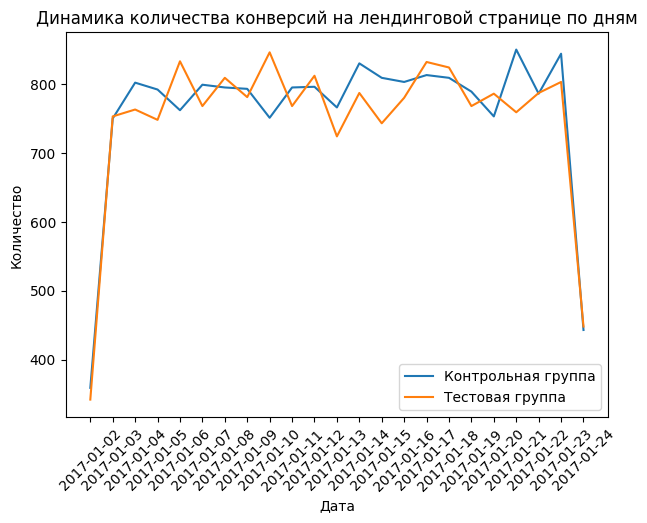

In [38]:
fig = plt.figure(figsize = (7, 5))

plt.plot(df_date_ctrl['date_only'],
         df_date_ctrl['converted_sum'],
         label = 'Контрольная группа')

plt.plot(df_date_test['date_only'],
         df_date_test['converted_sum'],
         label = 'Тестовая группа')

plt.title('Динамика количества конверсий на лендинговой странице по дням')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks (rotation= 45)

plt.legend()
plt.show()

In [39]:
df_date_test[df_date_test['date_only'] == '2017-01-06']

,index,group,date_only,user_count,converted_sum
4,27,treatment,2017-01-06,6747,833


In [40]:
df_date_ctrl[df_date_ctrl['date_only'] == '2017-01-06']

,group,date_only,user_count,converted_sum
4,control,2017-01-06,6606,762


In [41]:
df_date_ctrl.iloc[1:22]['converted_sum'].mean()

794.6190476190476

In [42]:
df_date_test.iloc[1:22]['converted_sum'].mean()

784.4761904761905

In [43]:
(df_date_ctrl.iloc[1:22]['converted_sum'].mean() +
df_date_test.iloc[1:22]['converted_sum'].mean()) / 2

789.547619047619

In [ ]:
# выделим отдельный столбец с датой 
df_res['hour_only'] = df_res['timestamp'].str.split(' ', n = 1, expand = False).apply(lambda x: x[1][:2])

/tmp/ipykernel_20/2141261666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['hour_only'] = df_res['timestamp'].str.split(' ', n = 1, expand = False).apply(lambda x: x[1][:2])


In [45]:
df_res

,user_id,timestamp,group,landing_page,converted,date_only,hour_only
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,2017-01-21,22
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,2017-01-12,08
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,2017-01-11,16
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,2017-01-08,18
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,2017-01-21,01
...,...,...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0,2017-01-03,22
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0,2017-01-12,00
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0,2017-01-22,11
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0,2017-01-15,01


In [46]:
# выделим отдельный столбец со значением часа, когда пользователь заходил на страницу
df_hour = df_res.groupby(['date_only', 'hour_only', 'group']).\
          agg(user_count = ('user_id', 'count'),
              converted_sum = ('converted', 'sum')).\
          reset_index()

df_hour

,date_only,hour_only,group,user_count,converted_sum
0,2017-01-02,13,control,83,11
1,2017-01-02,13,treatment,87,9
2,2017-01-02,14,control,272,39
3,2017-01-02,14,treatment,281,33
4,2017-01-02,15,control,247,33
...,...,...,...,...,...
1053,2017-01-24,11,treatment,252,33
1054,2017-01-24,12,control,272,35
1055,2017-01-24,12,treatment,276,37
1056,2017-01-24,13,control,174,22


In [ ]:
# расчитаем значение конверсии  и запишем в отдельный столбец
df_hour['CR'] = round(df_hour['converted_sum'] * 100 / df_hour['user_count'],2)
df_hour

,date_only,hour_only,group,user_count,converted_sum,CR
0,2017-01-02,13,control,83,11,13.25
1,2017-01-02,13,treatment,87,9,10.34
2,2017-01-02,14,control,272,39,14.34
3,2017-01-02,14,treatment,281,33,11.74
4,2017-01-02,15,control,247,33,13.36
...,...,...,...,...,...,...
1053,2017-01-24,11,treatment,252,33,13.10
1054,2017-01-24,12,control,272,35,12.87
1055,2017-01-24,12,treatment,276,37,13.41
1056,2017-01-24,13,control,174,22,12.64


In [48]:
# разделим на две группы: тестовую и контрольную
# сгруппируем по значению часа и оставим данные о конверсии и количестве пользователей
df_cr_ctrl = df_hour[df_hour['group'] == 'control'].\
            groupby(['group', 'hour_only'])[['CR', 'user_count']].\
            mean().reset_index()

df_cr_test = df_hour[df_hour['group'] == 'treatment'].\
            groupby(['group', 'hour_only'])[['CR', 'user_count']].\
            mean().reset_index()

Дополнительно были рассмотрены среднее количество пользователей и конверсия по часам в течение суток.




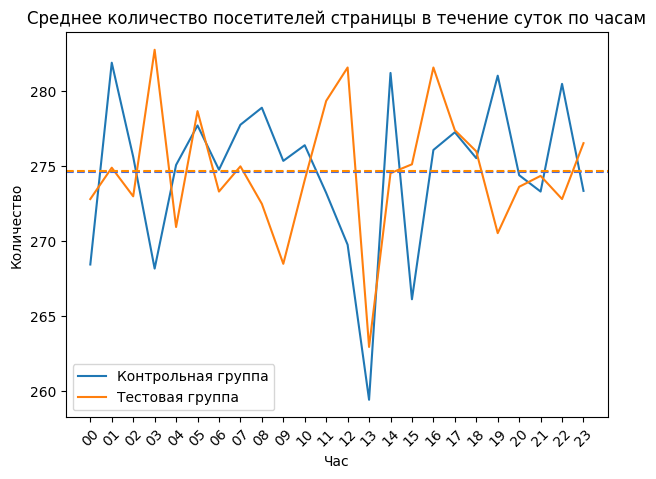

In [49]:
fig = plt.figure(figsize = (7, 5))

plt.plot(df_cr_ctrl['hour_only'],
         df_cr_ctrl['user_count'],
         label = 'Контрольная группа')

plt.plot(df_cr_test['hour_only'],
         df_cr_test['user_count'],
         label = 'Тестовая группа')

plt.title('Среднее количество посетителей страницы в течение суток по часам')
plt.xlabel('Час')
plt.ylabel('Количество')
plt.xticks (rotation= 45)

plt.axhline (y=df_cr_ctrl['user_count'].mean(), color='royalblue', linestyle='--')
plt.axhline (y=df_cr_test['user_count'].mean(), color='darkorange', linestyle='--')

plt.legend()
plt.show()

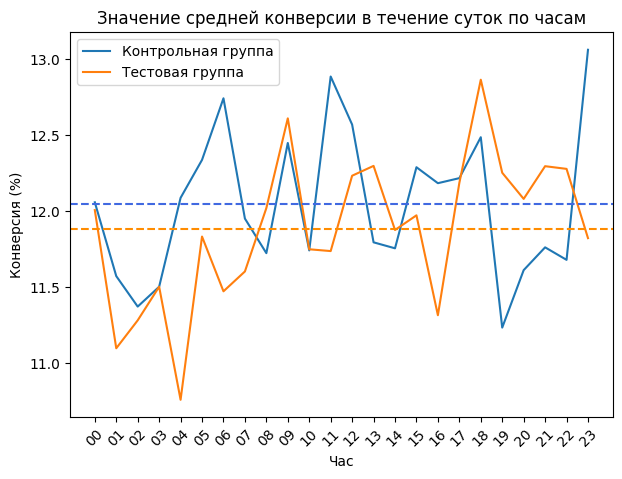

In [50]:
fig = plt.figure(figsize = (7, 5))

plt.plot(df_cr_ctrl['hour_only'],
         df_cr_ctrl['CR'],
         label = 'Контрольная группа')

plt.plot(df_cr_test['hour_only'],
         df_cr_test['CR'],
         label = 'Тестовая группа')

plt.title('Значение средней конверсии в течение суток по часам')
plt.xlabel('Час')
plt.ylabel('Конверсия (%)')
plt.xticks (rotation= 45)

plt.axhline (y=df_cr_ctrl['CR'].mean(), color='royalblue', linestyle='--')
plt.axhline (y=df_cr_test['CR'].mean(), color='darkorange', linestyle='--')

plt.legend()
plt.show()

In [51]:
print(f"Средняя конверсия в контрольной группе: \
      {round(df_cr_ctrl['CR'].mean(),2)}%")
print(f"Средняя конверсия в тестовой группе: \
      {round(df_cr_test['CR'].mean(),2)}%")

Средняя конверсия в контрольной группе:       12.04%
Средняя конверсия в тестовой группе:       11.88%
